# GIN — Fixed Architecture, Batch of Feature Configurations (HI-Small)

- **Question:** what do engineered edge features add when the GNN architecture is held *exactly* fixed?
- **Knobs per config:** `mp` = edge features in message passing (`none` / `base` / `full`), `readout` = edge features at the classifier (`base` / `full` / `gfp`). Direction and temporal sampling are fixed per batch.
- **Everything shared** (model template, training loop, threshold selection, metrics, plots, saving) lives in `gnn_core.py`. This notebook only sets `OPERATOR`, the config batch and paths.
- **Protocol:** threshold swept on validation each epoch, best-val-F1 checkpoint, test scored once; every metric on train / val / test. `invariant_params` must be **67,587** in every run.

## 0. Environment (Kaggle)

- Pinned PyTorch / PyG stack known to work on Kaggle GPU — do not change versions or order.
- Then clone (or pull) the public repo so the committed `gnn_core.py` is the one imported.

In [1]:
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib
!pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch_geometric

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 209.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 230.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 169.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 80.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 130.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 155.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import sys

REPO_URL = 'https://github.com/sandrokhizanishvili/gnn_for_fraudulent_patterns.git'
REPO_DIR = '/kaggle/working/gnn_for_fraudulent_patterns'
if os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull
else:
    !git clone {REPO_URL} {REPO_DIR}
!git -C {REPO_DIR} log -1 --oneline
sys.path.append(REPO_DIR)

Cloning into '/kaggle/working/gnn_for_fraudulent_patterns'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 64 (delta 26), reused 57 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 1.45 MiB | 6.42 MiB/s, done.
Resolving deltas: 100% (26/26), done.
f995f97 (HEAD -> main, origin/main, origin/HEAD) GIN notebook: seven configs (add GIN-6 base/gfp, GIN-7 none/gfp) in the EXPERIMENTS.md order; restructure EXPERIMENTS.md as a task list; drop re-score rule from CLAUDE.md; remove archived hidden-64 results/


## 1. Configuration

- The only cell that differs between operator notebooks (`GIN_` / `PNA_` / `GAT_`).
- `CONFIGS`: one dict per run of this batch; run numbers refer to `EXPERIMENTS.md`.
- `OUT_ROOT` mirrors `Outputs/GIN/` in the repo; the zip in section 6 is what gets committed (minus `best.pt`).

In [3]:
OPERATOR = 'gin'

# knob configs of this batch — one dict per run
CONFIGS = [
    dict(mp='none', readout='base'),   # GIN-1 — topology alone, the reference point
    dict(mp='base', readout='base'),   # GIN-2 — edge features inside message passing
    dict(mp='none', readout='full'),   # GIN-3 — GFP only at the decision layer
    dict(mp='full', readout='full'),   # GIN-4 — GFP everywhere
    dict(mp='base', readout='full'),   # GIN-5 — GFP at the decision layer only
    dict(mp='base', readout='gfp'),    # GIN-6 — are raw features redundant once message passing has used them?
    dict(mp='none', readout='gfp'),    # GIN-7 — GFP alone vs baseline alone (compare with GIN-1)
]
MP_DIRECTION      = 'in'     # 'in' | 'bidirectional' — fixed for the whole batch
TEMPORAL_SAMPLING = False    # True samples only edges earlier than the seed (needs pyg-lib)

# paths
DATA_DIR    = '/kaggle/input/datasets/sandrokhizanishvili/hi-small-gnn'
OUT_ROOT    = '/kaggle/working/Outputs/GIN'      # mirrors Outputs/GIN/ in the repo

import gnn_core as core
os.makedirs(OUT_ROOT, exist_ok=True)
print(f'torch {core.torch.__version__} | device {core.device} | gnn_core from {core.__file__}')

torch 2.8.0+cu126 | device cuda | gnn_core from /kaggle/working/gnn_for_fraudulent_patterns/gnn_core.py


## 2. Load graphs

- Three cumulative PyG snapshots; context edges carry label −1, only `eval_mask` edges are scored.
- `col_sets` maps each knob value to `edge_attr` columns: base = first 20, gfp = next 61, full = all 81.

In [4]:
graphs, col_sets, node_dim = core.load_graphs(DATA_DIR)

train nodes=515,070 edges=3,046,342 evaluated=3,046,342 laundering=2,297 (0.0754%)
val   nodes=515,070 edges=4,061,789 evaluated=1,015,447 laundering=1,082 (0.1066%)
test  nodes=515,070 edges=5,077,237 evaluated=1,015,448 laundering=1,143 (0.1126%)


## 3. Model

- Fixed template (`gnn_core.EdgeClassifier`): `node_proj` → 2 message-passing layers (hidden 128, dropout 0.3, residual) → readout MLP on `[h_src ‖ h_dst ‖ e_seed]`.
- `mp = none` → `GINConv`; otherwise `GINEConv(edge_dim)` adds only the edge projection `W_e`.
- Between configs only `W_e` and the readout's first `Linear` change width; `invariant_params` counts the rest and must be 67,587.

In [5]:
cfg = CONFIGS[0]
model = core.build_model(OPERATOR, node_dim, len(col_sets[cfg['mp']]), len(col_sets[cfg['readout']]),
                         MP_DIRECTION == 'bidirectional')
print(model)
print(f'params {core.count_params(model):,} | invariant_params {core.invariant_params(model):,}   (config {cfg})')
del model

EdgeClassifier(
  (node_proj): Linear(in_features=6, out_features=128, bias=True)
  (layers): ModuleList(
    (0-1): 2 x MPLayer(
      (conv_in): GINConv(nn=Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=128, bias=True)
      ))
      (dropout): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=276, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
params 103,043 | invariant_params 67,587   (config {'mp': 'none', 'readout': 'base'})


## 4. Run the batch

- One call per config: seed → model → loaders → 20 epochs → best checkpoint → all splits scored → `results.json`, `history.csv`, `curves.png`, `best.pt`, `predictions.csv` under `OUT_ROOT/<run>/`.
- `predictions.csv`: every evaluated edge of train / val / test with `edge_id` (= row in `Data/edge_features.csv`), `src`, `dst`, `edge_time`, `y`, `prob` (probability) and `pred` (class at the val-chosen threshold) — for the typology / error analyses.
- Per-epoch line: train / val loss, F1 (train at the val threshold), PR-AUC, seconds, RAM; `* new best` marks a checkpoint.

=== gin_mp-none_readout-base_dir-in ===
MP edge features: 0 | readout edge features: 20
total params: 103,043 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0146 / 0.0219 | F1 0.4429 / 0.4254 @ 0.466 | PR-AUC 0.3894 / 0.3613 | 48s | RAM 6.6GB   (train / val)
best validation F1 0.4401 at epoch 13 (threshold 0.502)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.4323  0.4387  0.3708
precision          0.5553  0.6940  0.4805
recall             0.3539  0.3207  0.3018
pr_auc             0.3684  0.3695  0.3283
roc_auc            0.9817  0.9752  0.9722
precision_at_5pct  0.0129  0.0175  0.0183
recall_at_5pct     0.8529  0.8235  0.8136
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GIN/gin_mp-none_readout-base_dir-in/predictions.csv


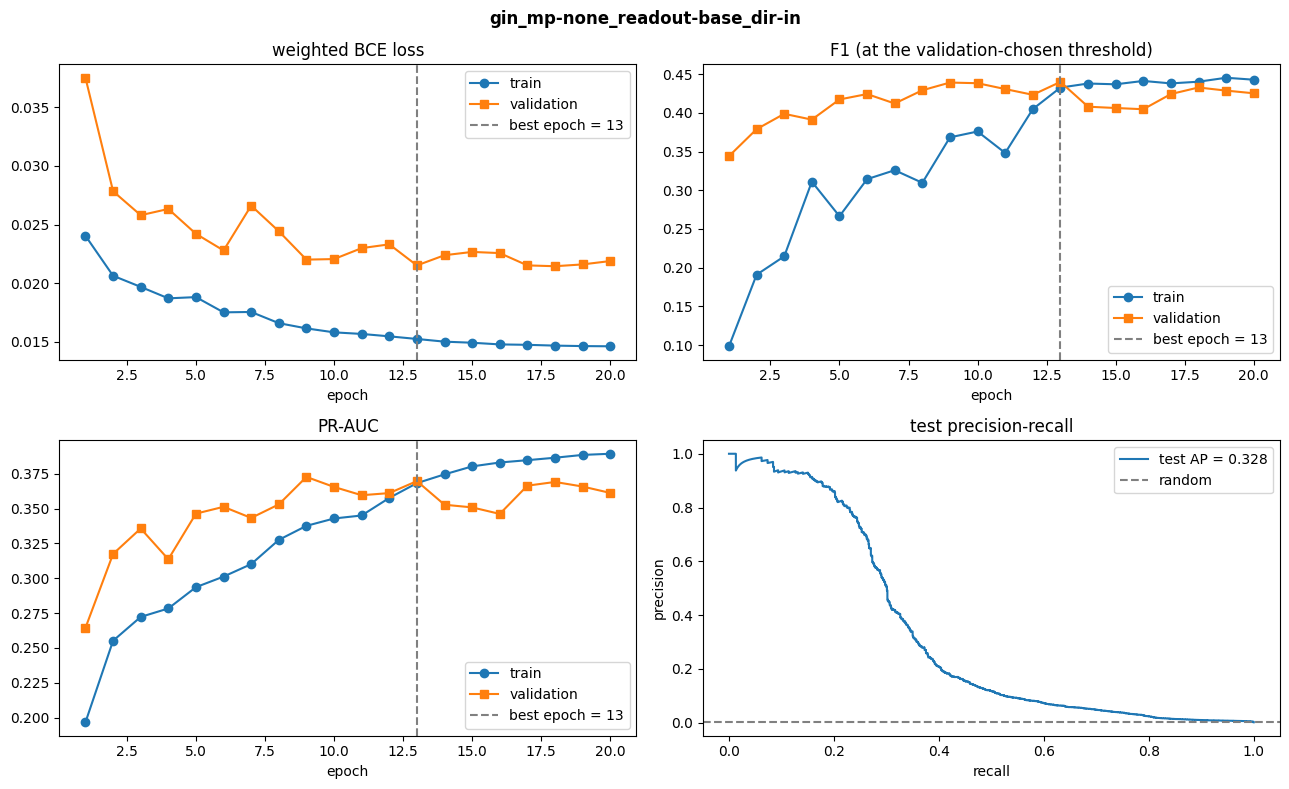

=== gin_mp-base_readout-base_dir-in ===
MP edge features: 20 | readout edge features: 20
total params: 108,419 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0114 / 0.0216 | F1 0.5611 / 0.5466 @ 0.553 | PR-AUC 0.5326 / 0.4772 | 69s | RAM 7.8GB   (train / val)
best validation F1 0.5544 at epoch 15 (threshold 0.486)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5480  0.5535  0.4556
precision          0.6499  0.8460  0.6589
recall             0.4737  0.4113  0.3482
pr_auc             0.5191  0.4716  0.3920
roc_auc            0.9887  0.9696  0.9612
precision_at_5pct  0.0136  0.0167  0.0174
recall_at_5pct     0.9047  0.7828  0.7708
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GIN/gin_mp-base_readout-base_dir-in/predictions.csv


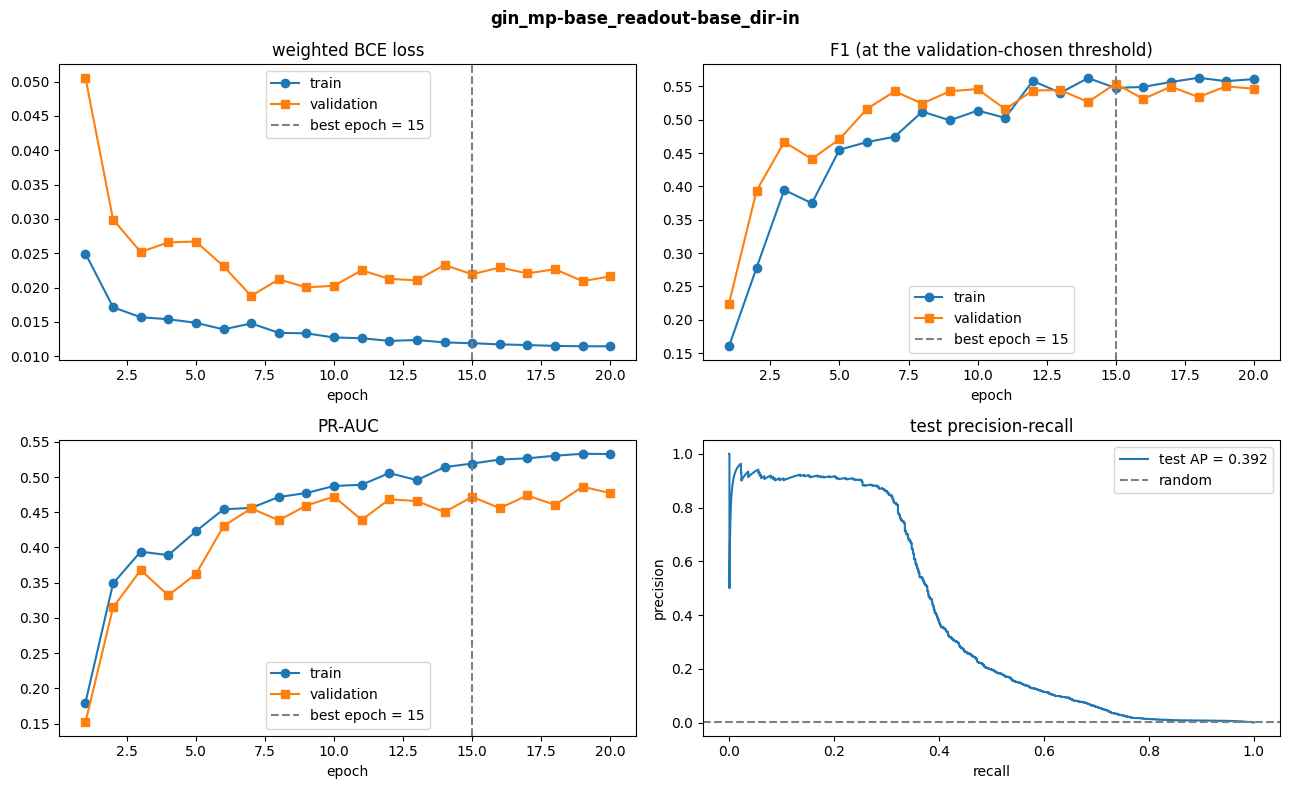

=== gin_mp-none_readout-full_dir-in ===
MP edge features: 0 | readout edge features: 81
total params: 110,851 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0136 / 0.0196 | F1 0.4755 / 0.5328 @ 0.518 | PR-AUC 0.4370 / 0.4757 | 47s | RAM 7.9GB   (train / val)
best validation F1 0.5475 at epoch 11 (threshold 0.561)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.4525  0.5478  0.4711
precision          0.5648  0.8127  0.6350
recall             0.3774  0.4131  0.3745
pr_auc             0.4099  0.4868  0.4348
roc_auc            0.9844  0.9812  0.9803
precision_at_5pct  0.0132  0.0184  0.0194
recall_at_5pct     0.8751  0.8614  0.8609
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GIN/gin_mp-none_readout-full_dir-in/predictions.csv


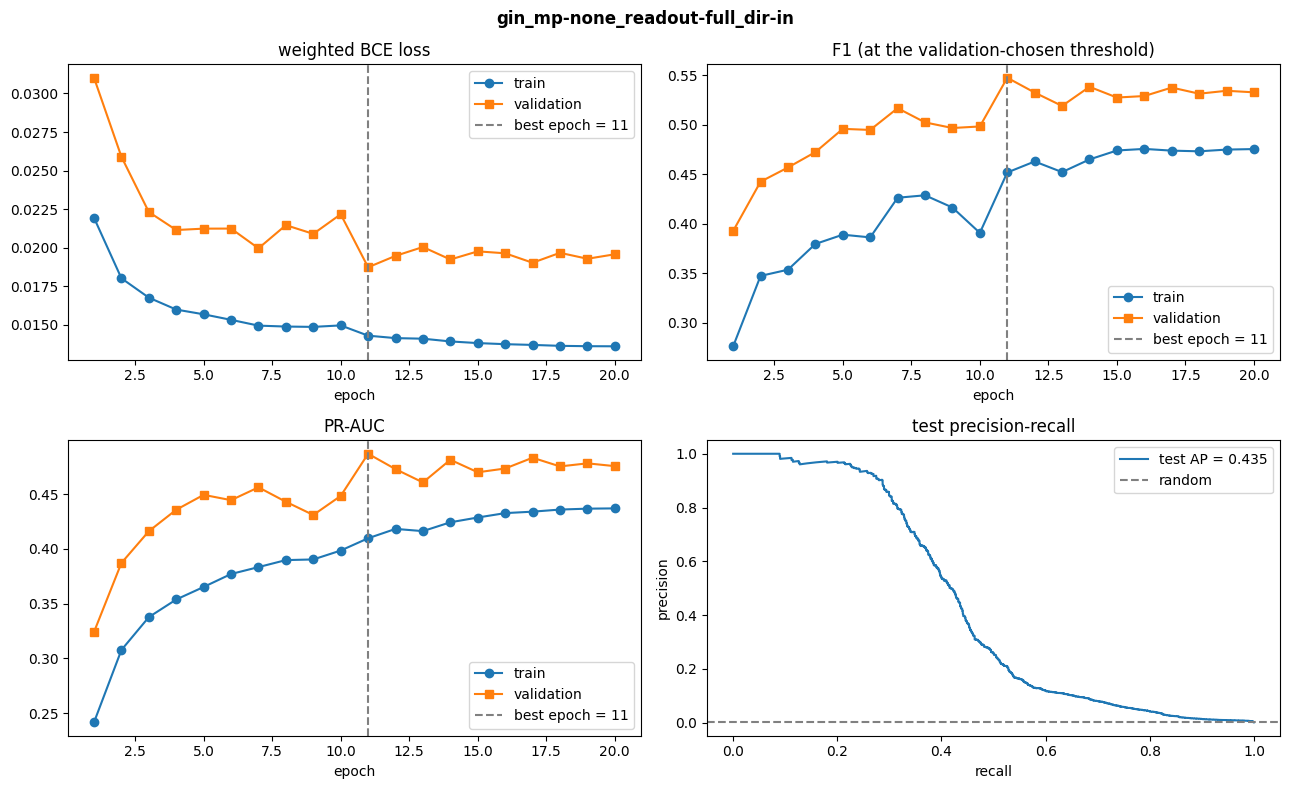

=== gin_mp-full_readout-full_dir-in ===
MP edge features: 81 | readout edge features: 81
total params: 131,843 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0090 / 0.0257 | F1 0.6085 / 0.5636 @ 0.711 | PR-AUC 0.6165 / 0.4900 | 131s | RAM 11.6GB   (train / val)
best validation F1 0.5980 at epoch 10 (threshold 0.568)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5634  0.5976  0.5118
precision          0.6923  0.8306  0.7433
recall             0.4750  0.4667  0.3902
pr_auc             0.5455  0.5379  0.4791
roc_auc            0.9908  0.9793  0.9740
precision_at_5pct  0.0140  0.0178  0.0186
recall_at_5pct     0.9282  0.8373  0.8268
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GIN/gin_mp-full_readout-full_dir-in/predictions.csv


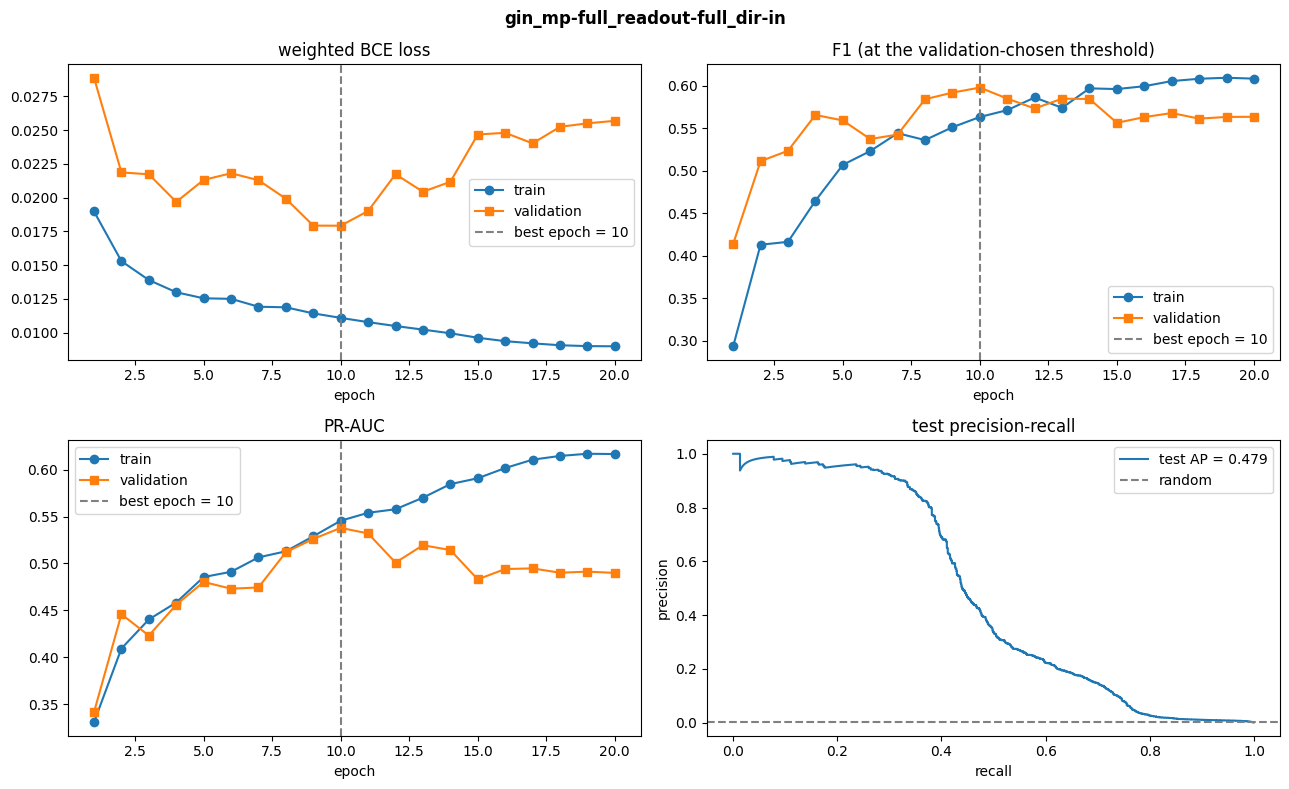

=== gin_mp-base_readout-full_dir-in ===
MP edge features: 20 | readout edge features: 81
total params: 116,227 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0110 / 0.0191 | F1 0.5766 / 0.5915 @ 0.596 | PR-AUC 0.5434 / 0.5333 | 69s | RAM 8.9GB   (train / val)
best validation F1 0.6098 at epoch 8 (threshold 0.504)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5339  0.6089  0.5252
precision          0.6664  0.8200  0.6777
recall             0.4454  0.4843  0.4287
pr_auc             0.4823  0.5488  0.4837
roc_auc            0.9860  0.9825  0.9802
precision_at_5pct  0.0134  0.0184  0.0195
recall_at_5pct     0.8855  0.8641  0.8670
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GIN/gin_mp-base_readout-full_dir-in/predictions.csv


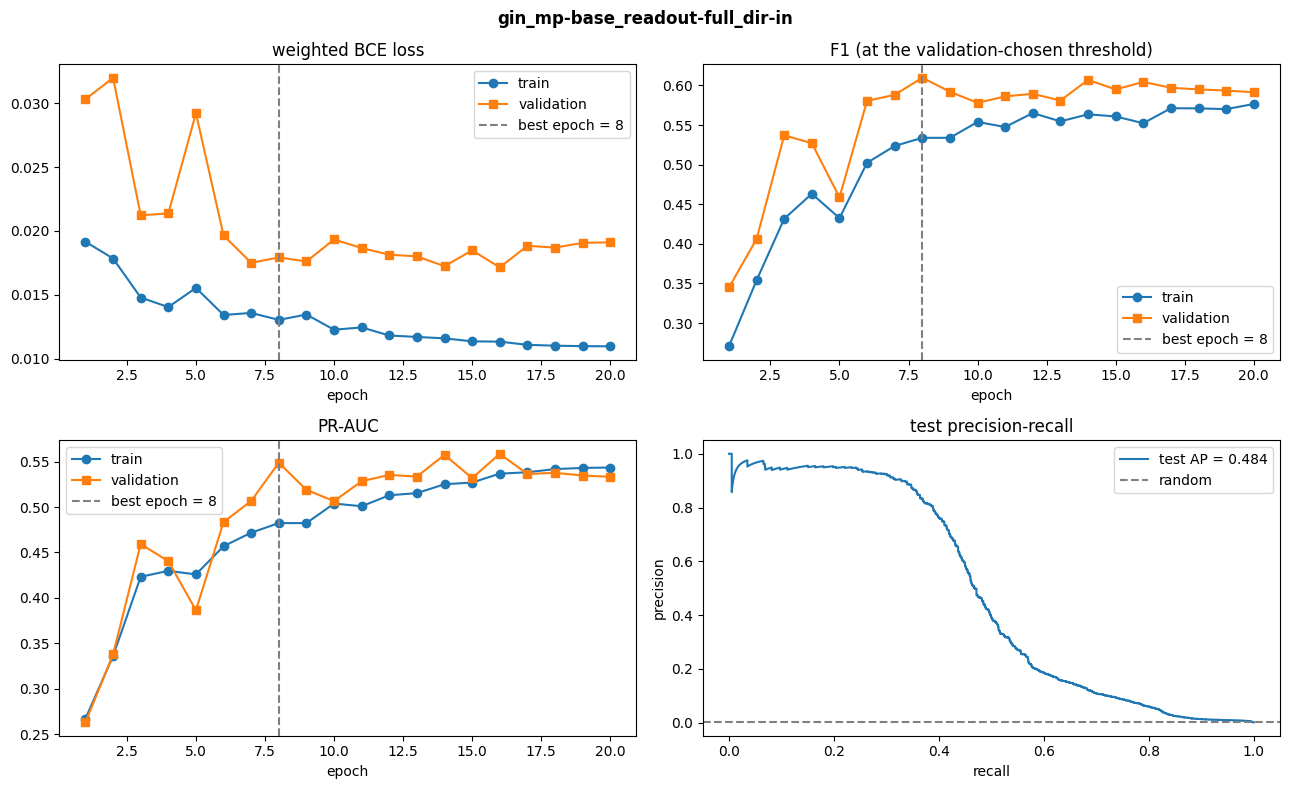

=== gin_mp-base_readout-gfp_dir-in ===
MP edge features: 20 | readout edge features: 61
total params: 113,667 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0121 / 0.0217 | F1 0.5253 / 0.5300 @ 0.650 | PR-AUC 0.4928 / 0.4632 | 68s | RAM 8.6GB   (train / val)
best validation F1 0.5328 at epoch 19 (threshold 0.646)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5257  0.5328  0.4395
precision          0.7071  0.6776  0.5074
recall             0.4184  0.4390  0.3876
pr_auc             0.4925  0.4637  0.3949
roc_auc            0.9885  0.9706  0.9607
precision_at_5pct  0.0137  0.0171  0.0173
recall_at_5pct     0.9108  0.8013  0.7699
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GIN/gin_mp-base_readout-gfp_dir-in/predictions.csv


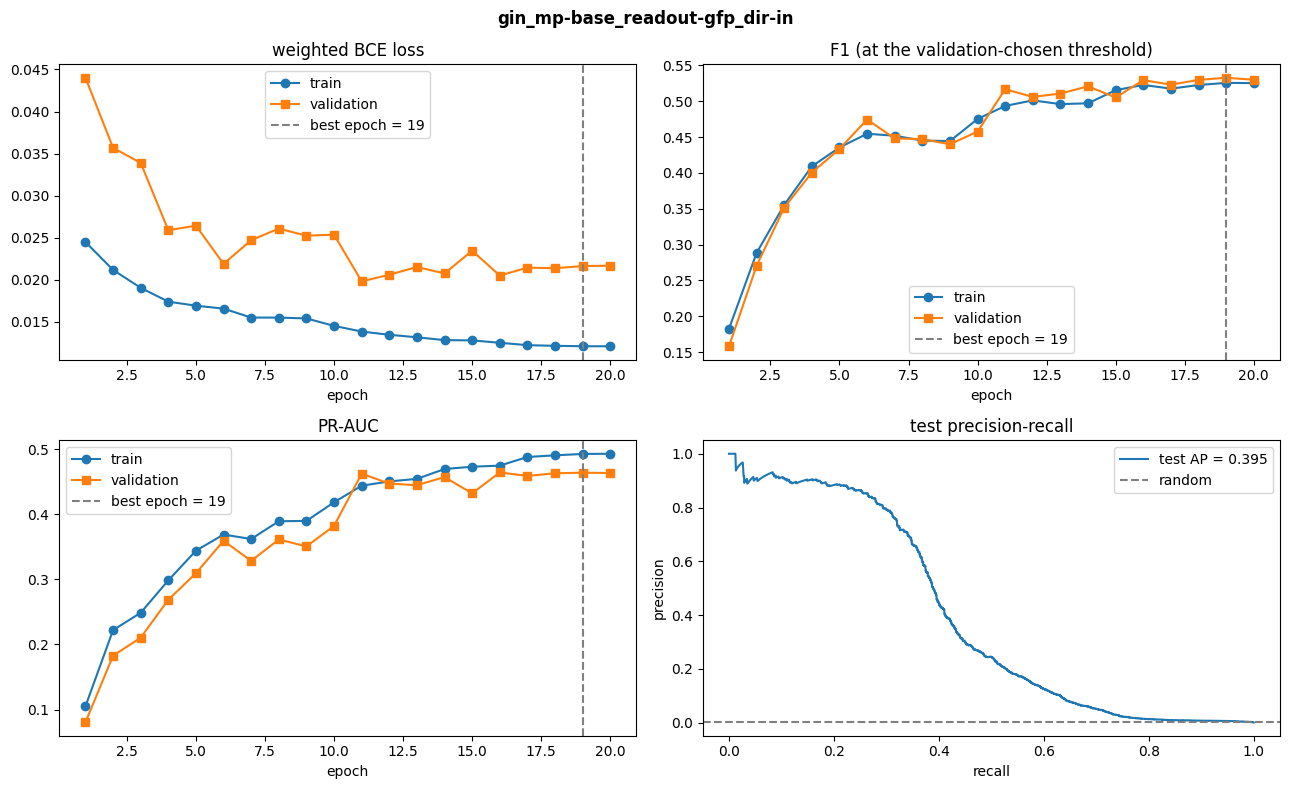

=== gin_mp-none_readout-gfp_dir-in ===
MP edge features: 0 | readout edge features: 61
total params: 108,291 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0190 / 0.0261 | F1 0.2722 / 0.3203 @ 0.685 | PR-AUC 0.2467 / 0.2397 | 47s | RAM 7.7GB   (train / val)   * new best -> best.pt
best validation F1 0.3203 at epoch 20 (threshold 0.685)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.2728  0.3191  0.2561
precision          0.6860  0.4577  0.2652
recall             0.1702  0.2449  0.2476
pr_auc             0.2465  0.2393  0.1975
roc_auc            0.9651  0.9548  0.9414
precision_at_5pct  0.0118  0.0164  0.0164
recall_at_5pct     0.7797  0.7708  0.7305
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GIN/gin_mp-none_readout-gfp_dir-in/predictions.csv


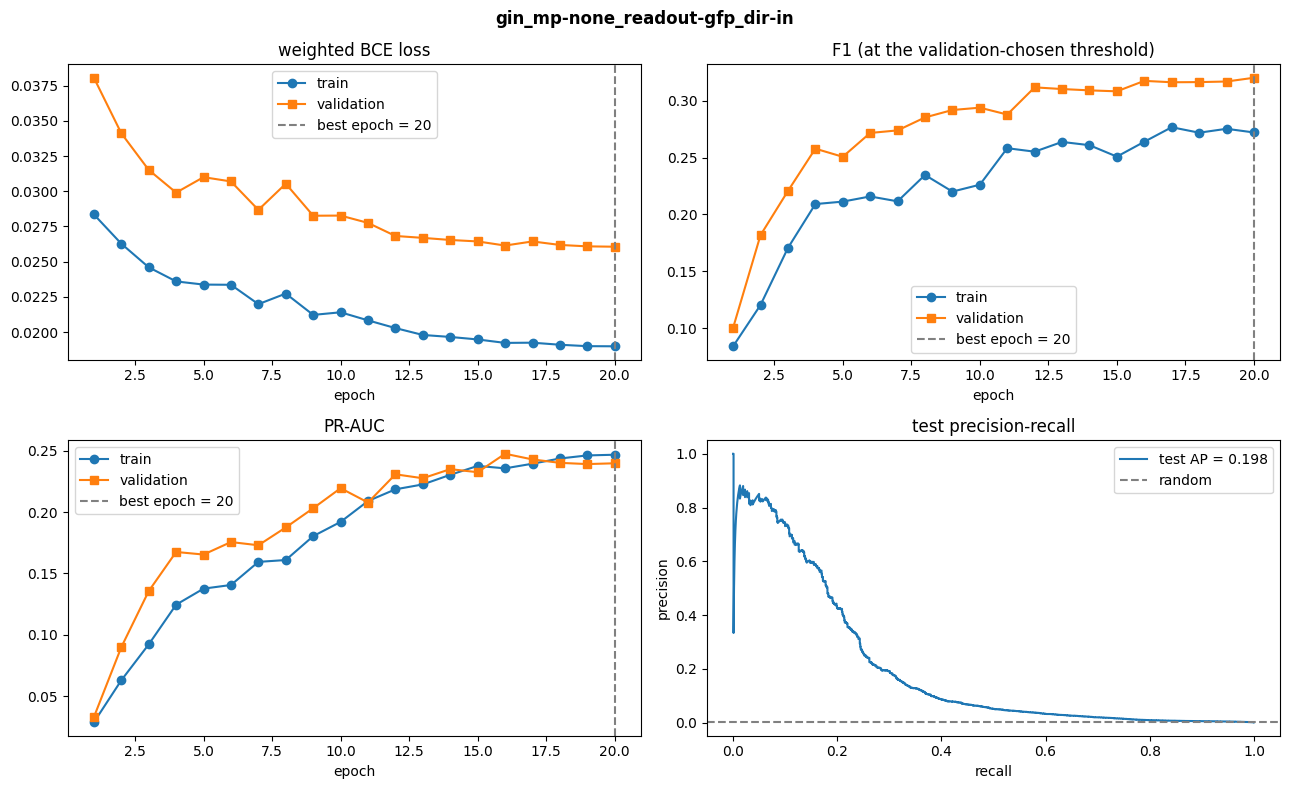

batch complete


In [6]:
rows = []
for cfg in CONFIGS:
    print('=' * 90)
    rows.append(core.run_experiment(OPERATOR, cfg, graphs, col_sets, node_dim, OUT_ROOT,
                                    MP_DIRECTION, TEMPORAL_SAMPLING))
print('=' * 90)
print('batch complete')

## 5. Comparison across the batch

- `batch_summary.csv` holds every `<split>_<metric>` column plus `threshold`, `best_epoch`, `params`, `invariant_params`.
- `invariant_params` must be identical in every row (asserted).

In [7]:
summary = core.summarize_batch(rows, OUT_ROOT)
summary[core.DISPLAY_COLS].round(4)

7 runs -> /kaggle/working/Outputs/GIN/batch_summary.csv | invariant_params = 67,587 in every row


,run,best_epoch,threshold,val_f1,test_f1,test_precision,test_recall,test_pr_auc,test_precision_at_5pct,test_recall_at_5pct,params,invariant_params
0,gin_mp-none_readout-base_dir-in,13,0.5020,0.4387,0.3708,0.4805,0.3018,0.3283,0.0183,0.8136,103043,67587
1,gin_mp-base_readout-base_dir-in,15,0.4858,0.5535,0.4556,0.6589,0.3482,0.3920,0.0174,0.7708,108419,67587
2,gin_mp-none_readout-full_dir-in,11,0.5610,0.5478,0.4711,0.6350,0.3745,0.4348,0.0194,0.8609,110851,67587
3,gin_mp-full_readout-full_dir-in,10,0.5679,0.5976,0.5118,0.7433,0.3902,0.4791,0.0186,0.8268,131843,67587
4,gin_mp-base_readout-full_dir-in,8,0.5036,0.6089,0.5252,0.6777,0.4287,0.4837,0.0195,0.8670,116227,67587
5,gin_mp-base_readout-gfp_dir-in,19,0.6456,0.5328,0.4395,0.5074,0.3876,0.3949,0.0173,0.7699,113667,67587
6,gin_mp-none_readout-gfp_dir-in,20,0.6854,0.3191,0.2561,0.2652,0.2476,0.1975,0.0164,0.7305,108291,67587


## 6. Download

- Zip `OUT_ROOT`; extract into `Outputs/GIN/` in the repo and commit the small result files (`best.pt` and `predictions.csv` stay out of git).

In [8]:
import shutil
shutil.make_archive(f'/kaggle/working/Outputs_{OPERATOR.upper()}', 'zip', OUT_ROOT)

'/kaggle/working/Outputs_GIN.zip'